In [1]:
# -------------------------------------
# 
# extract data for a given site
# 
# -------------------------------------
import os 

import icechunk 
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
import xarray as xr

mplstyle.use('fast')

era5_dir = "era5/preprocessed_icechunk"
era5_bucket = "carbonplan-carbon-removal"

# --- read in 
storage = icechunk.s3_storage(bucket=era5_bucket, prefix=era5_dir, from_env=True)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")
rtds = xr.open_zarr(session.store, consolidated=False)
rtds

<xarray.Dataset> Size: 354GB
Dimensions:                        (time: 184104, latitude: 105, longitude: 241)
Coordinates:
  * longitude                      (longitude) float32 964B 235.0 ... 295.0
  * latitude                       (latitude) float32 420B 50.0 49.75 ... 24.0
    level                          int64 8B ...
  * time                           (time) datetime64[ns] 1MB 2000-01-01 ... 2...
Data variables: (12/19)
    2m_temperature                 (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    geopotential                   (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    evaporation                    (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    land_sea_mask                  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    runoff                         (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    skin_reservoir_content         (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    ...                             ...
    total_precipitation            (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_3  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_4  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_2  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    volumetric_soil_water_layer_1  (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
    sub_surface_runoff             (time, latitude, longitude) float32 19GB dask.array<chunksize=(184104, 12, 12), meta=np.ndarray>
Attributes:
    last_updated:           2025-07-23 01:54:31.932125+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-17

In [2]:
# --- select given site
mintime = '2000-01-01'
maxtime = '2010-12-31'
site_dict = {
    "site_1": {'xlat': 38.148, 'xlon': 360 -121.449, 'name': 'central valley'},    # central valley
    "site_2": {'xlat': 44.764, 'xlon': 360 -93.202, 'name': 'minneapolis'},     # minneapolis
    "site_3": {'xlat': 33.584, 'xlon': 360 -83.828, 'name': 'atlanta'},     # atlanta
    "site_4": {'xlat': 42.582, 'xlon': 360 -74.029, 'name': 'albany'},     # albany
}

# --- generate ds of these points 
dslist = []
for site, coords in site_dict.items():
    tmpds = rtds.sel(latitude=coords['xlat'], longitude=coords['xlon'], method='nearest').sel(time=slice(mintime, maxtime))
    tmpds = tmpds.expand_dims(site=[coords['name']]).copy()
    dslist.append(tmpds)

dsx = xr.concat(dslist, dim='site')

In [12]:
# --- plot 
def plot_var_timeseries(
    pvar: str,
    ds: xr.Dataset,
    site_dict: dict,
    savepath: str,
    save_on: bool=True,
): 
    '''
    Plot a single variable. Save a plot for every site
    in the ds.
    '''
    allsites = ds.site.values

    for site in allsites:
        # ... pull out this specific site
        site_idx = next((k for k, v in site_dict.items() if v['name'] == site), None)
        # and the data
        ds_site = ds.sel(site = site).copy()

        # ... get the data across time horizons
        pall = ds_site[pvar]
        # group by month with start frequency on first to get monthly means
        pmonthly = ds_site[pvar].resample(time='1MS').mean()
        # get long term monthly mean
        clim_repeated = xr.DataArray(      # to plot 1-12 over and over for the dsx['time'] period
            data=dsx['time.month'].values,
            coords={'time': dsx['time']},
            dims='time'
        )
        pmonthly_ltm = ds_site[pvar].groupby('time.month').mean(dim='time').sel(month=clim_repeated)
        # get long term annual mean
        pannual = ds_site[pvar].groupby('time.year').mean(dim='time').mean(dim='year')


        # --- generate plot 
        plt.axhline(y=pannual.values, color='red', linestyle='--', lw=1, label='annual_ltm')
        plt.plot(pall.time, pall, color='black', lw=0.5, label='hourly')
        plt.plot(pmonthly.time, pmonthly, color='orange', label='monthly')
        plt.plot(pmonthly_ltm.time, pmonthly_ltm, color='steelblue', lw=3, label='monthly_ltm')
        plt.legend()
        plt.xlabel('time')
        plt.ylabel(pvar)
        plt.title(f'{pvar} | {site_idx}: {site}')
        plt.yscale('log')

        if save_on:
            savename = f'{pvar}_{site_idx}_{dsx['time.year'].min().values}-{dsx['time.year'].max().values}.png'
            plt.savefig(os.path.join(savepath, savename), dpi=300)

        plt.close();



def plot_multivar_timeseries(
    pvars: list,
    multivar_name: str,
    ds: xr.Dataset,
    site_dict: dict,
    savepath: str,
    save_on: bool=True,
    showplot: bool=False
): 
    '''
    Plot a single variable. Save a plot for every site
    in the ds.
    '''
    allsites = ds.site.values

    for site in allsites:
        # ... pull out this specific site
        site_idx = next((k for k, v in site_dict.items() if v['name'] == site), None)
        # and the data
        ds_site = ds.sel(site = site).copy()

        # ... get the data across time horizons
        for pvar in pvars:
            pall = ds_site[pvar]
            
            # --- generate plot 
            plt.plot(pall.time, pall, lw=0.85, label=f'{pvar}')
            # plt.title(f'{pvar} | {site_idx}: {site}')
            plt.yscale('log')
        plt.legend()
        plt.xlabel('time')
        plt.ylabel(pvar)
        plt.title(f'{multivar_name} | {site_idx}: {site}')
        
        if showplot:
            plt.show();

        if save_on:
            savename = f'Multivar_{multivar_name}_{site_idx}_{dsx['time.year'].min().values}-{dsx['time.year'].max().values}.png'
            plt.savefig(os.path.join(savepath, savename), dpi=300)

        plt.close();




def plot_var_map(
    pvar: str,
    ds_ann: xr.Dataset,
    site_dict: dict,
    savepath: str,
    save_on: bool=True,
    land_only: bool=True
): 
    '''
    plot map of variable in mean annual. assume input dataset 
    is already in the mean annual
    '''

    # --- PLOT 
    if land_only:
        ax = ds_ann[pvar].where(ds_ann['land_sea_mask']>0.1).plot()
    else: 
        ax = ds_ann[pvar].plot()
    # add site markers and labels
    for key, site in site_dict.items():
        x = site['xlon']
        y = site['xlat'] 
        # plot point
        plt.scatter(x, y, color='black', marker='o', zorder=10)
        # add label
        plt.text(x + 0.5, y + 0.2, key, fontsize=9, color='black', zorder=11)

    plt.title(f"{pvar}")

    if save_on:
        savename = f'{pvar}_{site_idx}_{dsx['time.year'].min().values}-{dsx['time.year'].max().values}_ANN.png'
        plt.savefig(os.path.join(savepath, savename), dpi=300)

    plt.close();


In [72]:
# --- [ PLOT MAPS ]
pvars = [
    # [ optional ]
    'evaporation', 
    'skin_reservoir_content', 
    'potential_evaporation', 
    'runoff',
    # [ main ]
    '2m_temperature', 
    'soil_type', 
    'sub_surface_runoff', 
    # [ other ]
    'total_precipitation', 
    'soil_temperature_level_1', 'soil_temperature_level_2', 
    'soil_temperature_level_3', 'soil_temperature_level_4', 
    'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 
    'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4'
    ]

savepath = '/home/tykukla/ew-workflows/era5/figures/maps'
ds_ann = rtds.groupby('time.year').mean(dim='time').mean(dim='year').copy()

# --- loop through vars
for pvar in pvars:
    print(f'Now plotting {pvar}')
    plot_var_map(
        pvar,
        ds_ann,
        site_dict,
        savepath,
        save_on=True,
        land_only=True
    )


Now plotting evaporation
Now plotting skin_reservoir_content
Now plotting potential_evaporation
Now plotting runoff
Now plotting 2m_temperature
Now plotting soil_type
Now plotting sub_surface_runoff
Now plotting total_precipitation
Now plotting soil_temperature_level_1
Now plotting soil_temperature_level_2
Now plotting soil_temperature_level_3
Now plotting soil_temperature_level_4
Now plotting volumetric_soil_water_layer_1
Now plotting volumetric_soil_water_layer_2
Now plotting volumetric_soil_water_layer_3
Now plotting volumetric_soil_water_layer_4


In [73]:
# --- [ PLOT TIMESERIES ]
pvars = [
    # [ optional ]
    'evaporation', 
    'skin_reservoir_content', 
    'potential_evaporation', 
    'runoff',
    # [ main ]
    '2m_temperature', 
    # 'soil_type', 
    'sub_surface_runoff', 
    # [ other ]
    'total_precipitation', 
    'soil_temperature_level_1', 'soil_temperature_level_2', 
    'soil_temperature_level_3', 'soil_temperature_level_4', 
    'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 
    'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4'
    ]

savepath = '/home/tykukla/ew-workflows/era5/figures/timeseries'

# --- loop through vars
for pvar in pvars:
    print(f'Now plotting {pvar}')
    plot_var_timeseries(
        pvar,
        ds=dsx,
        site_dict=site_dict,
        savepath=savepath,
        save_on=True,
    )


Now plotting evaporation
Now plotting skin_reservoir_content
Now plotting potential_evaporation
Now plotting runoff
Now plotting 2m_temperature
Now plotting sub_surface_runoff
Now plotting total_precipitation
Now plotting soil_temperature_level_1
Now plotting soil_temperature_level_2
Now plotting soil_temperature_level_3
Now plotting soil_temperature_level_4
Now plotting volumetric_soil_water_layer_1
Now plotting volumetric_soil_water_layer_2
Now plotting volumetric_soil_water_layer_3
Now plotting volumetric_soil_water_layer_4


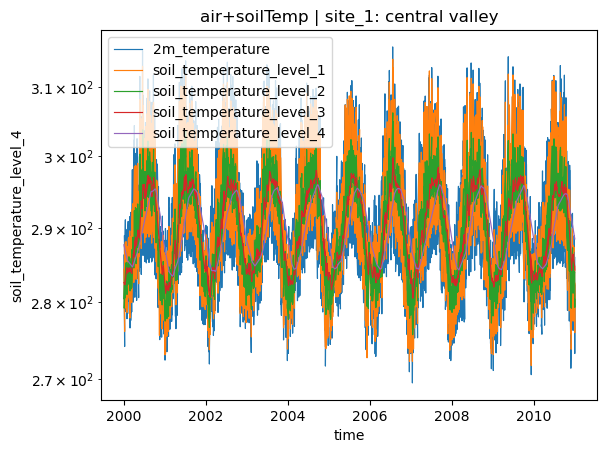

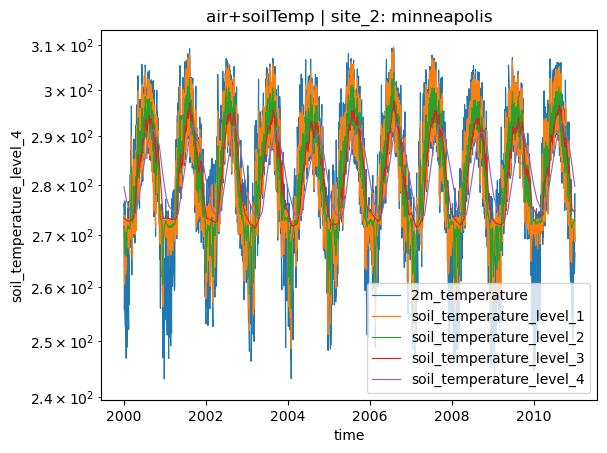

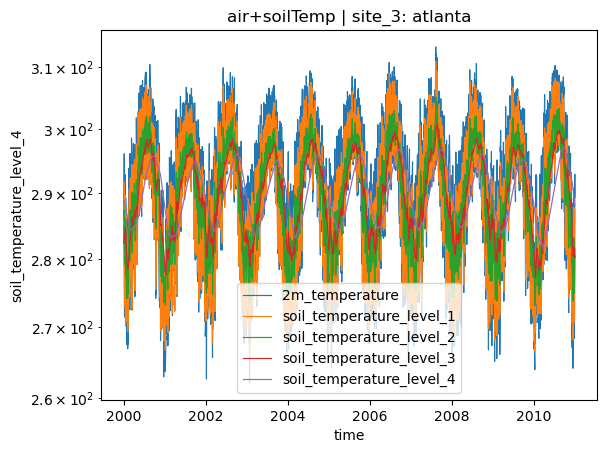

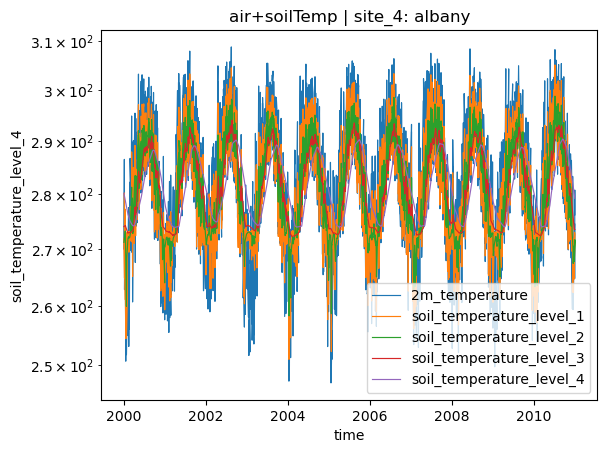

In [13]:
# --- compare vars to plot 
savepath = '/home/tykukla/ew-workflows/era5/figures/timeseries'

# [ soil. temperature ]
multivar_name = "air+soilTemp"
pvars = ["2m_temperature", "soil_temperature_level_1",
        "soil_temperature_level_2", "soil_temperature_level_3",
        "soil_temperature_level_4"]

plot_multivar_timeseries(
    pvars,
    multivar_name,
    ds=dsx,
    site_dict=site_dict,
    savepath=savepath,
    save_on=False,
    showplot=True,
)

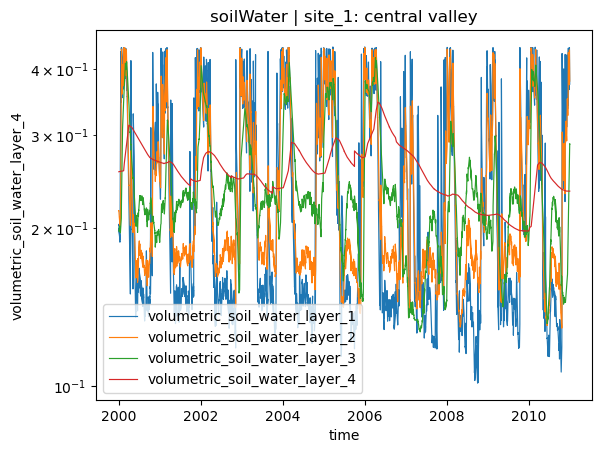

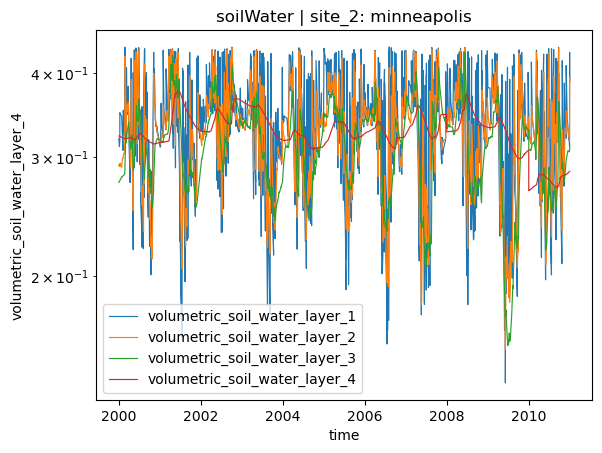

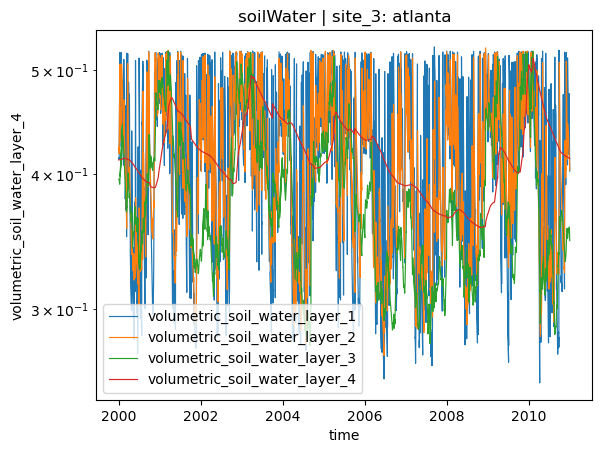

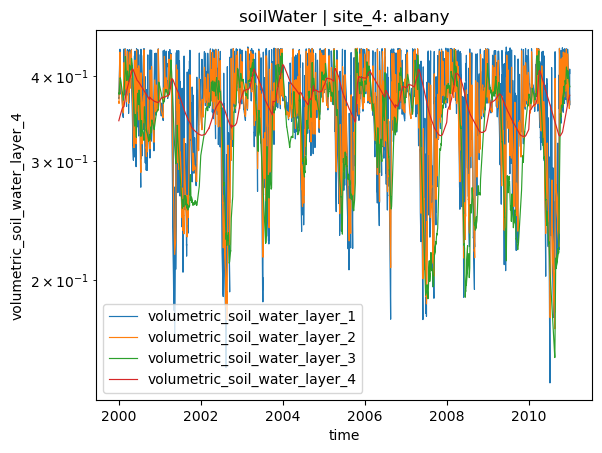

In [14]:
# --- compare vars to plot 
savepath = '/home/tykukla/ew-workflows/era5/figures/timeseries'

# [ soil. temperature ]
multivar_name = "soilWater"
pvars = ["volumetric_soil_water_layer_1", 
        "volumetric_soil_water_layer_2",
        "volumetric_soil_water_layer_3",
        "volumetric_soil_water_layer_4",
        ]


plot_multivar_timeseries(
    pvars,
    multivar_name,
    ds=dsx,
    site_dict=site_dict,
    savepath=savepath,
    save_on=False,
    showplot=True,
)